<a href="https://colab.research.google.com/github/jeffrey-su/B101-Group2-NLP-Project/blob/main/DetectorModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [1]:
!pip install numpy torch datasets transformers sentencepiece protobuf accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


In [2]:
import os
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy
import torch

# **Dataset**

Loading our csv into a df and converting to HF Dataset

In [3]:
train_df = pd.read_csv('/content/train_subtype_stratified.csv')
val_df = pd.read_csv('/content/val_subtype_stratified.csv')

combined_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"Shape of train_df: {train_df.shape}")
print(f"Shape of val_df: {val_df.shape}")
print(f"Shape of combined_df: {combined_df.shape}")
display(combined_df.head())

Shape of train_df: (4320, 3)
Shape of val_df: (1080, 3)
Shape of combined_df: (5400, 3)


,sample_text,sub-type,AI_label
0,"The novel study, An immunotoxin targeting Ebo...",abstract,1
1,Phase change materials (Sb and Te alloys) are ...,abstract,0
2,Who will get them? I am happy to sit down wit...,email,0
3,This article presents a novel investigation o...,abstract,1
4,Covid-19 numbers keep soaring as travelers sca...,news,0


In [4]:
df_path = r"/content/train_subtype_stratified.csv"
df_dataset = pd.read_csv(df_path)

raw_dataset = Dataset.from_pandas(combined_df)

# encode the AI_label column into type ClassLabel
raw_dataset = raw_dataset.class_encode_column("AI_label")

Stringifying the column:   0%|          | 0/5400 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]

Creating a test/train split, split evenly between class labels

In [5]:
dataset = raw_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True, stratify_by_column="AI_label")

# rename test set to val
dataset["val"] = dataset.pop("test")

dataset

DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1080
    })
})

# **Fine-Tuning Prep**

## **Tokenizing**

In [6]:
model = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model, use_fast=True)

tokenizer

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

DebertaV2Tokenizer(name_or_path='microsoft/deberta-v3-small', vocab_size=128000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [7]:
def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=350)
  tokenized["labels"] = example["AI_label"]
  return tokenized

In [8]:
tokenized_dataset = dataset.map(tokenize, batched=True, remove_columns=["sample_text"])
tokenized_dataset

Map:   0%|          | 0/4320 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sub-type', 'AI_label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sub-type', 'AI_label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1080
    })
})

## **Metrics Setup**

In [9]:
import numpy as np
import evaluate
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits = eval_pred.predictions # Correctly access predictions attribute
    labels = eval_pred.label_ids  # Correctly access label_ids attribute
    preds = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]

    # Precision, Recall, F1 (macro + weighted)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    # ROC AUC
    try:
        auc = roc_auc_score(labels, logits[:,1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "auc": auc,
    }

## **Training Config**

In [38]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    seed=42,
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-5,
    warmup_ratio=0.1,
    max_grad_norm=1.0,
    fp16=False,                           # prevent overflow
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    metric_for_best_model="f1",
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifie

In [41]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels, id2label=id2label, label2id=label2id)

import torch
from transformers import TrainingArguments, EarlyStoppingCallback

training_args = TrainingArguments(
    seed=42,
    output_dir="./results_subtype_stratified",

    # 1. EPOCHS & BATCH SIZE
    num_train_epochs=3,                     # 3 epochs max (810 total steps)
    per_device_train_batch_size=16,         # Batch size 16 (or 8 with grad_accum=2)
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=1,

    # 2. LEARNING RATE & SCHEDULER
    learning_rate=1.5e-5,                   # Conservative LR for transformer backbone
    lr_scheduler_type="cosine",             # Smooth decay prevents late-stage divergence
    warmup_steps=80,                        # ~10% of total training steps

    # 3. OPTIMIZER & STABILITY (Crucial for DeBERTa-v3 / RoBERTa)
    optim="adamw_torch_fused",              # Eliminates position embedding variance explosion
    adam_epsilon=1e-6,                      # Prevents numerical underflow / NaN gradients
    max_grad_norm=0.5,                      # Strict gradient clipping

    # 4. REGULARIZATION
    weight_decay=0.01,                      # L2 regularization
    label_smoothing_factor=0.05,            # Slight smoothing to prevent logit overconfidence

    # 5. PRECISION
    fp16=False,                             # Keep False for DeBERTa FP16 stability
    bf16=torch.cuda.is_bf16_supported(),    # Safe on Ampere GPUs (RTX 30xx/40xx, A100)

    # 6. EVALUATION & CHECKPOINTING
    eval_strategy="steps",
    eval_steps=45,                          # Evaluates ~6 times per epoch (every 45 steps)
    save_strategy="steps",
    save_steps=45,
    save_total_limit=2,
    logging_steps=15,

    # 7. MODEL SELECTION
    metric_for_best_model="f1",
    greater_is_better=True,
    load_best_model_at_end=True,
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifie

In [43]:
from transformers import Trainer, EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

trainer.train()

NameError: name 'tokenized_train_dataset' is not defined

In [42]:
trainer.train()

AttributeError: `AcceleratorState` object has no attribute `distributed_type`. This happens if `AcceleratorState._reset_state()` was called and an `Accelerator` or `PartialState` was not reinitialized.

OPTUNA RUN

In [44]:
!pip install -q optuna

import os
import torch
import gc
import numpy as np
import pandas as pd
import optuna
import evaluate
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
from datasets import Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback)

gc.collect()
torch.cuda.empty_cache()
train_df = pd.read_csv('/content/train_subtype_stratified.csv')
val_df = pd.read_csv('/content/val_subtype_stratified.csv')

raw_dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df),
    "val": Dataset.from_pandas(val_df)
})

checkpoint = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=True)

def tokenize_function(example):
    tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=384)
    tokenized["labels"] = example["AI_label"]
    return tokenized

tokenized_dataset = raw_dataset.map(tokenize_function, batched=True, remove_columns=["sample_text"])

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred.predictions, eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    _, _, f1_macro, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)

    try:
        auc = roc_auc_score(labels, logits[:, 1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "auc": auc
    }

#optuna init
id2label = {0: "Human-Written", 1: "AI-Generated"}
label2id = {"Human-Written": 0, "AI-Generated": 1}

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        num_labels=2,
        id2label=id2label,
        label2id=label2id
    )

#optuna obj
def objective(trial):
    #clean memory between runs
    gc.collect()
    torch.cuda.empty_cache()

    #hyperparams given by gemini
    lr = trial.suggest_float("learning_rate", 5e-6, 3e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.001, 0.1, log=True)
    warmup_steps = trial.suggest_int("warmup_steps", 40, 150)
    batch_size = trial.suggest_categorical("per_device_train_batch_size", [8, 16])
    label_smoothing = trial.suggest_float("label_smoothing_factor", 0.0, 0.1)

    training_args = TrainingArguments(
        output_dir=f"./results_trial_{trial.number}",
        seed=42,
        num_train_epochs=3,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=16,

        learning_rate=lr,
        lr_scheduler_type="cosine",
        warmup_steps=warmup_steps,

        optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
        adam_epsilon=1e-6,
        max_grad_norm=0.5,

        weight_decay=weight_decay,
        label_smoothing_factor=label_smoothing,

        fp16=False,
        bf16=torch.cuda.is_bf16_supported(),

        logging_steps=15,
        eval_strategy="steps",
        eval_steps=45,
        save_strategy="steps",
        save_steps=45,
        save_total_limit=1,

        metric_for_best_model="accuracy",
        greater_is_better=True,
        load_best_model_at_end=True,
        report_to="none"
    )

    trainer = Trainer(
        model_init=model_init,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["val"],
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    eval_metrics = trainer.evaluate()
    val_accuracy = eval_metrics["eval_accuracy"]

    train_loss = eval_metrics.get("eval_loss", 0.1)
    composite_score = val_accuracy - (0.1 * train_loss)

    return composite_score
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=8)

print("\n" + "="*50)
print(" BEST HYPERPARAMETERS")
print("="*50)
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")
print(f" Best Score: {study.best_value:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 14.7 MB/s eta 0:00:00


Map:   0%|          | 0/4320 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

[I 2026-08-05 20:00:10,996] A new study created in memory with name: no-name-cd0b5940-4377-4ab0-b723-c3efa8a134d6


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Step,Accuracy,F1 Macro,Auc
0.700402,0.579049,225,0.749074,0.729138,0.735425


[I 2026-08-05 20:54:33,644] Trial 7 finished with value: 0.6911691630328144 and parameters: {'learning_rate': 2.6777726586979427e-05, 'weight_decay': 0.011585505811343492, 'warmup_steps': 124, 'per_device_train_batch_size': 16, 'label_smoothing_factor': 0.036381409655596574}. Best is trial 5 with value: 0.8690138261627268.



 BEST HYPERPARAMETERS FOUND 
  learning_rate: 1.0317194532819815e-05
  weight_decay: 0.0258640555020671
  warmup_steps: 114
  per_device_train_batch_size: 16
  label_smoothing_factor: 0.041141631299109915
 Best Score: 0.8690


In [ ]:
import torch
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1}
)

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./deberta_v3_best",

    # Optuna Best Parameters
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1.0317e-05,
    weight_decay=0.02586,
    warmup_steps=114,
    label_smoothing_factor=0.04114,

    lr_scheduler_type="cosine",
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    adam_epsilon=1e-6,
    max_grad_norm=0.5,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=45,
    save_strategy="steps",
    save_steps=45,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

# Run full final training run
trainer.train()

# Save final tuned model weights and tokenizer
trainer.save_model("./deberta_v3_final")
tokenizer.save_pretrained("./deberta_v3_final")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  286MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

model.safetensors: reconstructing file:   0%|          |  0.00B /  286MB            

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./deberta_v3_ai_detector_final/tokenizer_config.json',
 './deberta_v3_ai_detector_final/tokenizer.json')

In [11]:
!zip -r deberta_v3_ai_detector_best.zip deberta_v3_ai_detector_best/

  adding: deberta_v3_ai_detector_best/ (stored 0%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/ (stored 0%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/optimizer.pt (deflated 87%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/config.json (deflated 55%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/training_args.bin (deflated 53%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/scheduler.pt (deflated 61%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/model.safetensors (deflated 8%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/trainer_state.json (deflated 77%)
  adding: deberta_v3_ai_detector_best/checkpoint-315/rng_state.pth (deflated 26%)


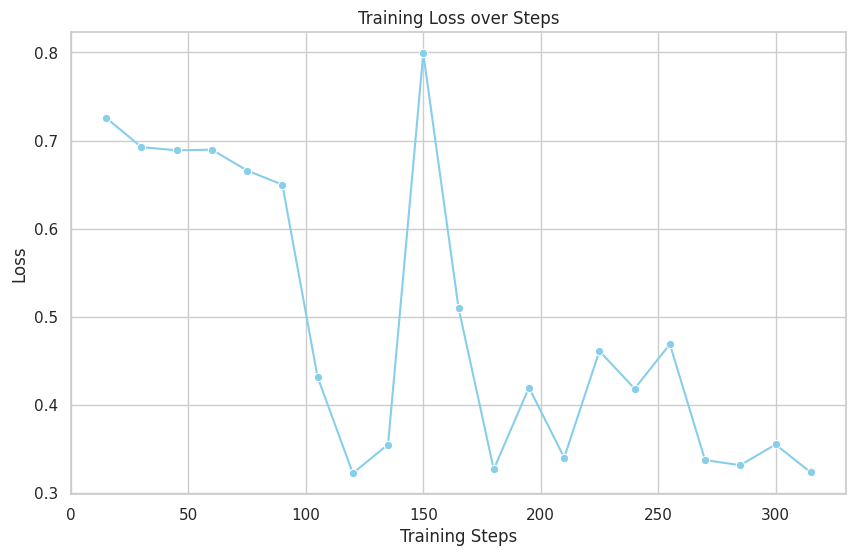

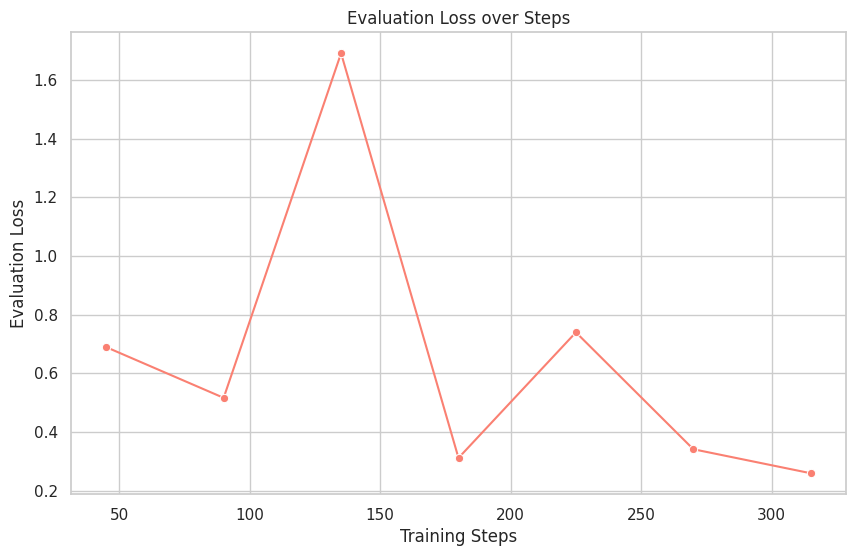

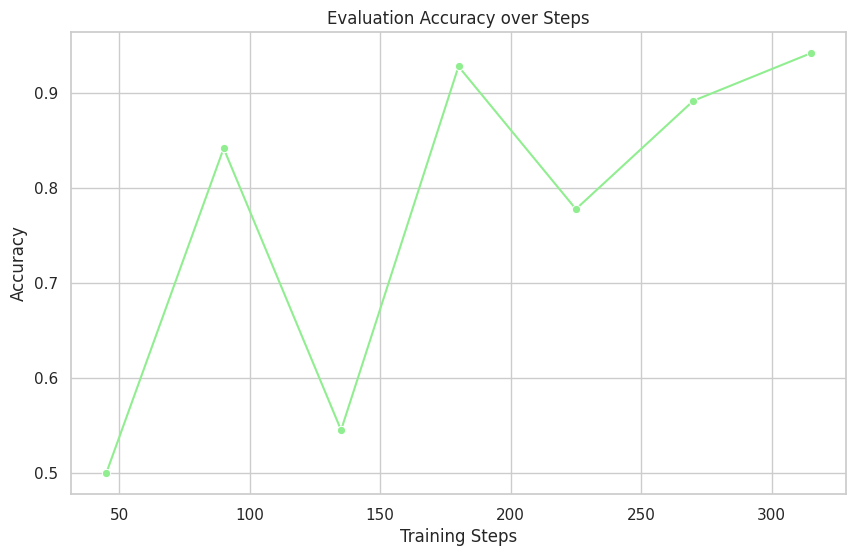

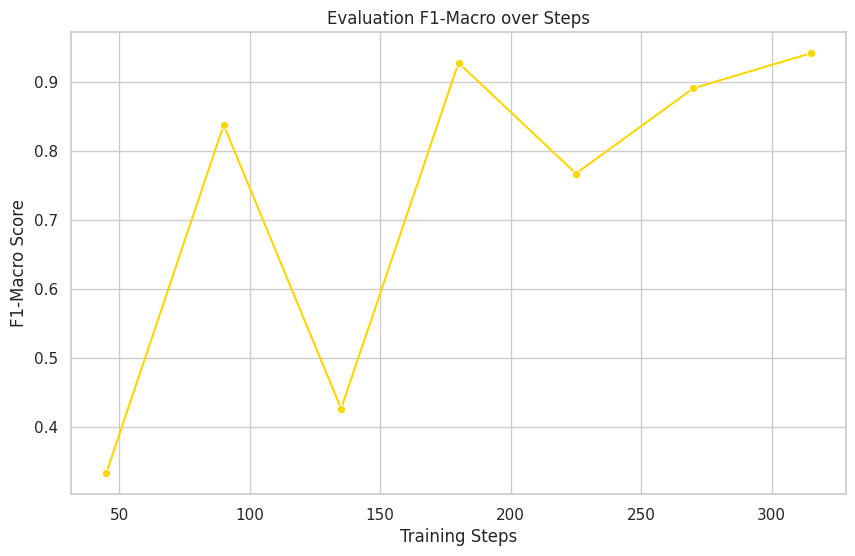

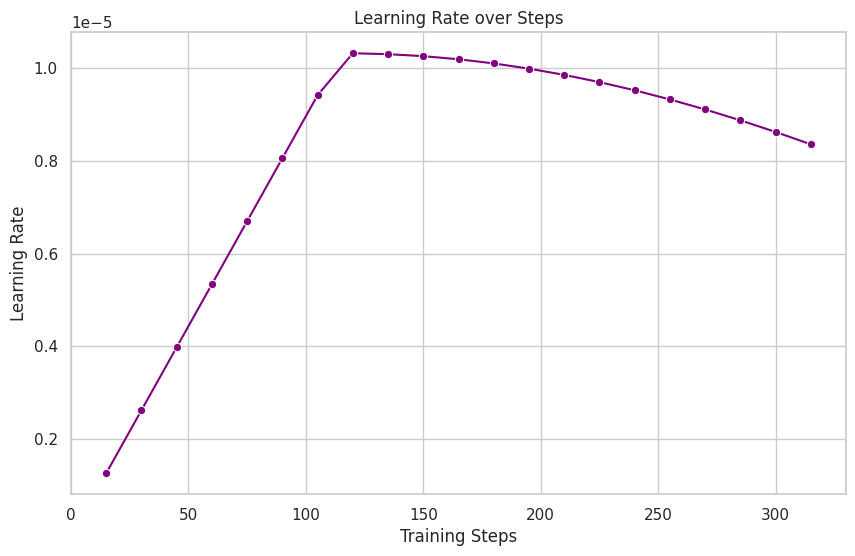

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

# Define the path to the trainer_state.json file
# Assuming the best model was saved in a checkpoint within deberta_v3_ai_detector_best
# Let's find the latest checkpoint to get the trainer_state.json
model_dir = './deberta_v3_ai_detector_best'
checkpoints = [d for d in os.listdir(model_dir) if os.path.isdir(os.path.join(model_dir, d)) and 'checkpoint' in d]
checkpoints.sort(key=lambda x: int(x.split('-')[1]), reverse=True)

# Create a directory to save the plots
output_plot_dir = './metric_graphs'
os.makedirs(output_plot_dir, exist_ok=True)

if checkpoints:
    latest_checkpoint = checkpoints[0]
    trainer_state_path = os.path.join(model_dir, latest_checkpoint, 'trainer_state.json')
else:
    print("No checkpoints found in deberta_v3_ai_detector_best. Cannot load trainer_state.json")
    trainer_state_path = None


if trainer_state_path and os.path.exists(trainer_state_path):
    with open(trainer_state_path, 'r') as f:
        trainer_state = json.load(f)

    log_history = trainer_state.get('log_history', [])

    # Filter out evaluation steps from training steps
    train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
    eval_logs = [log for log in log_history if 'eval_loss' in log]

    # Extract training metrics
    train_steps = [log['step'] for log in train_logs]
    train_loss = [log['loss'] for log in train_logs]
    train_learning_rate = [log['learning_rate'] for log in train_logs]

    # Extract evaluation metrics
    eval_steps = [log['step'] for log in eval_logs]
    eval_loss = [log['eval_loss'] for log in eval_logs]
    eval_accuracy = [log['eval_accuracy'] for log in eval_logs]
    eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]

    sns.set_theme(style="whitegrid")

    # Plot Training Loss
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=train_steps, y=train_loss, marker='o', color='skyblue')
    plt.title('Training Loss over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig(os.path.join(output_plot_dir, 'training_loss.png'))
    plt.show()

    # Plot Evaluation Loss
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=eval_steps, y=eval_loss, marker='o', color='salmon')
    plt.title('Evaluation Loss over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Evaluation Loss')
    plt.grid(True)
    plt.savefig(os.path.join(output_plot_dir, 'eval_loss.png'))
    plt.show()

    # Plot Evaluation Accuracy
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=eval_steps, y=eval_accuracy, marker='o', color='lightgreen')
    plt.title('Evaluation Accuracy over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.savefig(os.path.join(output_plot_dir, 'eval_accuracy.png'))
    plt.show()

    # Plot Evaluation F1-Macro
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=eval_steps, y=eval_f1_macro, marker='o', color='gold')
    plt.title('Evaluation F1-Macro over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('F1-Macro Score')
    plt.grid(True)
    plt.savefig(os.path.join(output_plot_dir, 'eval_f1_macro.png'))
    plt.show()

    # Plot Learning Rate
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=train_steps, y=train_learning_rate, marker='o', color='purple')
    plt.title('Learning Rate over Steps')
    plt.xlabel('Training Steps')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.savefig(os.path.join(output_plot_dir, 'learning_rate.png'))
    plt.show()
else:
    print(f"Trainer state file not found at {trainer_state_path}. Unable to generate metric graphs.")

In [14]:
!zip -r metric_graphs.zip metric_graphs/

  adding: metric_graphs/ (stored 0%)
  adding: metric_graphs/eval_f1_macro.png (deflated 10%)
  adding: metric_graphs/eval_accuracy.png (deflated 11%)
  adding: metric_graphs/learning_rate.png (deflated 12%)
  adding: metric_graphs/training_loss.png (deflated 8%)
  adding: metric_graphs/eval_loss.png (deflated 10%)


BIG BLOCK HYPERPARAM CHECK - I didnt get through all of this, only made it through the LR stuff

In [ ]:
import gc
import torch
import pandas as pd
import numpy as np
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

baseline_params = {
    "learning_rate": 1.0e-05,
    "weight_decay": 0.01,
    "warmup_steps": 115,
    "per_device_train_batch_size": 16,
    "label_smoothing_factor": 0.05,
}

param_variations = {
    "learning_rate": [1.0e-06, 1.0e-05, 1.0e-04],
    "weight_decay": [0.005, 0.01, 0.025],
    "warmup_steps": [50, 115, 200],
    "per_device_train_batch_size": [8, 16, 32],
    "label_smoothing_factor": [0.0, 0.05, 0.1],
}

def model_init():
    return AutoModelForSequenceClassification.from_pretrained(
        "microsoft/deberta-v3-small",
        num_labels=2,
        id2label={0: "Human-Written", 1: "AI-Generated"},
        label2id={"Human-Written": 0, "AI-Generated": 1},
    )

results = []
run_count = 1

for param_name, values in param_variations.items():
    print(f"\n==========================================")
    print(f" TESTING HYPERPARAMETER: {param_name} ")
    print(f"==========================================")

    for val in values:
        current_config = baseline_params.copy()
        current_config[param_name] = val

        print(f"\n[Run {run_count}/15] {param_name} = {val}")

        gc.collect()
        torch.cuda.empty_cache()

        training_args = TrainingArguments(
            seed=42,
            output_dir=f"./results_grid_{param_name}_{val}",
            num_train_epochs=3,


            per_device_train_batch_size=current_config["per_device_train_batch_size"],
            per_device_eval_batch_size=16,
            learning_rate=current_config["learning_rate"],
            weight_decay=current_config["weight_decay"],
            warmup_steps=current_config["warmup_steps"],
            label_smoothing_factor=current_config["label_smoothing_factor"],


            lr_scheduler_type="cosine",
            optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
            adam_epsilon=1e-6,
            max_grad_norm=0.5,

            fp16=False,
            bf16=torch.cuda.is_bf16_supported(),

            eval_strategy="steps",
            eval_steps=45,
            save_strategy="steps",
            save_steps=45,
            save_total_limit=1,
            logging_steps=15,

            metric_for_best_model="accuracy",
            greater_is_better=True,
            load_best_model_at_end=True,
            report_to="none"
        )

        trainer = Trainer(
            model_init=model_init,
            args=training_args,
            train_dataset=tokenized_dataset["train"],
            eval_dataset=tokenized_dataset["val"],
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )
        trainer.train()

        metrics = trainer.evaluate()

        results.append({
            "tested_parameter": param_name,
            "tested_value": val,
            "eval_accuracy": metrics["eval_accuracy"],
            "eval_f1_macro": metrics["eval_f1_macro"],
            "eval_loss": metrics["eval_loss"]
        })

        run_count += 1

summary_df = pd.DataFrame(results)
display(summary_df.sort_values(by=["tested_parameter", "eval_accuracy"], ascending=[True, False]))


 TESTING HYPERPARAMETER: learning_rate 

[Run 1/15] learning_rate = 1e-06


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

...

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.weight                       | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.de

Step,Training Loss,Validation Loss
